In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

# 下载并加载 Cora
dataset = Planetoid(root='./data/Cora', name='Cora')
data = dataset[0]

print(f"节点数：{data.num_nodes}")           # 2708
print(f"边数：{data.num_edges}")             # 10556（双向，所以是 5429×2）
print(f"节点特征维度：{data.num_features}")  # 1433
print(f"类别数：{dataset.num_classes}")      # 7
print(f"训练节点数：{data.train_mask.sum()}") # 140
print(f"验证节点数：{data.val_mask.sum()}")   # 500
print(f"测试节点数：{data.test_mask.sum()}")  # 1000

/home/goose/DL/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


节点数：2708
边数：10556
节点特征维度：1433
类别数：7
训练节点数：140
验证节点数：500
测试节点数：1000


In [2]:
# 查看 mask 的含义
print(data.train_mask[:10])  # True 表示该节点用于训练
print(data.y[:10])           # 节点标签（0-6）

tensor([True, True, True, True, True, True, True, True, True, True])
tensor([3, 4, 4, 0, 3, 2, 0, 3, 3, 2])


/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 25454 (\N{CJK UNIFIED IDEOGRAPH-636E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/3360915536.py:21: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAP

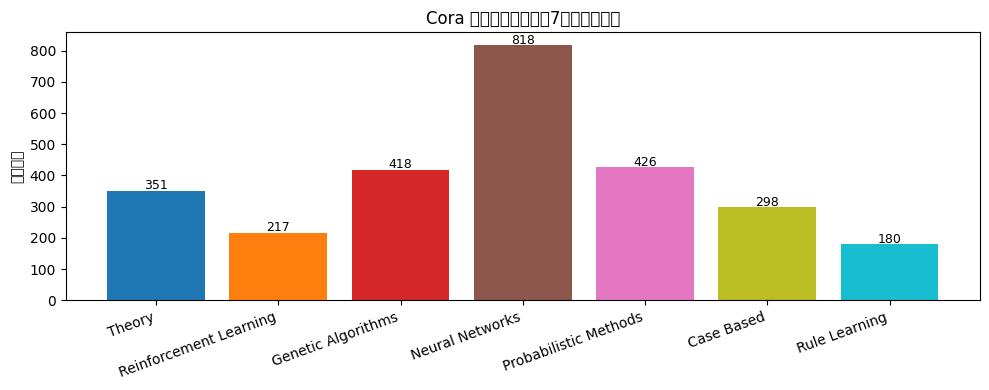

In [3]:
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    'Theory', 'Reinforcement Learning', 'Genetic Algorithms',
    'Neural Networks', 'Probabilistic Methods',
    'Case Based', 'Rule Learning'
]

labels = data.y.numpy()
class_counts = [(labels == i).sum() for i in range(7)]

plt.figure(figsize=(10, 4))
bars = plt.bar(class_names, class_counts, color=plt.cm.tab10(np.linspace(0, 1, 7)))
plt.xticks(rotation=20, ha='right')
plt.ylabel("节点数量")
plt.title("Cora 数据集类别分布（7个研究领域）")
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 21069 (\N{CJK UNIFIED IDEOGRAPH-524D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/850914062.py:13: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS

特征矩阵稀疏度：98.73%


/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


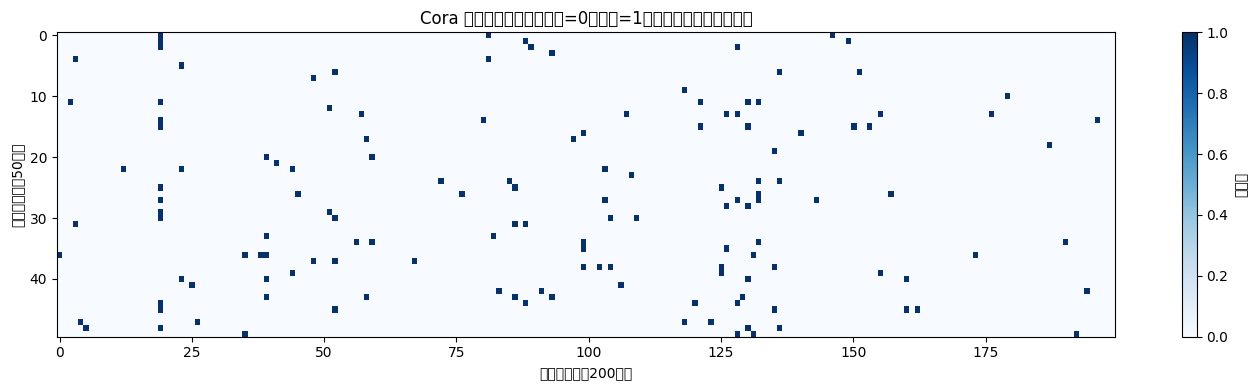

In [4]:
# 计算特征矩阵的稀疏度
features = data.x.numpy()
sparsity = (features == 0).mean()
print(f"特征矩阵稀疏度：{sparsity:.2%}")  # 预期约 99%

# 可视化前50个节点的特征热力图
plt.figure(figsize=(14, 4))
plt.imshow(features[:50, :200], aspect='auto', cmap='Blues', interpolation='none')
plt.colorbar(label='特征值')
plt.xlabel("特征维度（前200维）")
plt.ylabel("节点编号（前50个）")
plt.title("Cora 节点特征热力图（白色=0，蓝色=1）可以看到特征非常稀疏")
plt.tight_layout()
plt.show()

/tmp/ipykernel_71974/540581773.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32593 (\N{CJK UNIFIED IDEOGRAPH-7F51}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/goose/DL/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32476 (\N{CJK UNIFIED IDEOGRAPH-7EDC}) missing from font(s) DejaVu Sans.
  fig.

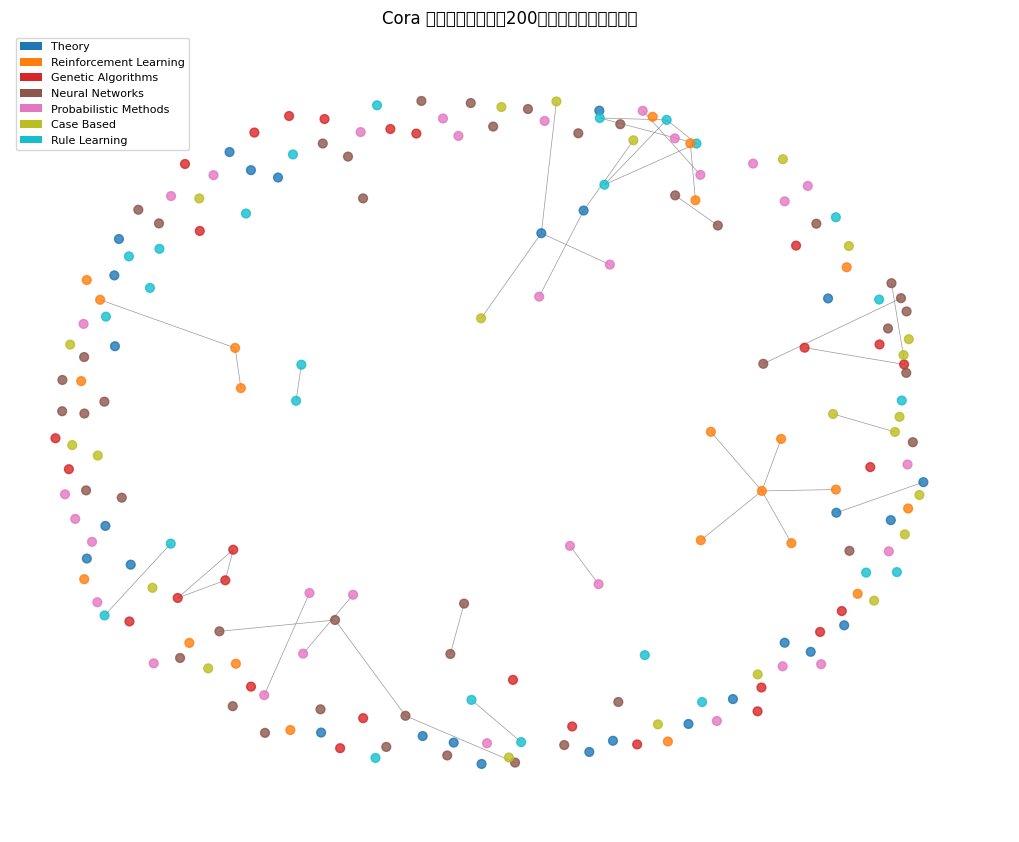

In [5]:
import networkx as nx

# 采样：取前200个节点构成的子图
edge_index_np = data.edge_index.numpy()
mask = (edge_index_np[0] < 200) & (edge_index_np[1] < 200)
edges = list(zip(edge_index_np[0][mask], edge_index_np[1][mask]))

G_sub = nx.Graph()
G_sub.add_nodes_from(range(200))
G_sub.add_edges_from(edges)

# 按类别着色
node_colors = [plt.cm.tab10(data.y[i].item() / 6.0) for i in range(200)]

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_sub, seed=42, k=0.3)
nx.draw(G_sub, pos,
        node_color=node_colors,
        node_size=40,
        edge_color='gray',
        alpha=0.8,
        width=0.5,
        with_labels=False)

# 图例
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=plt.cm.tab10(i/6.0), label=class_names[i])
                   for i in range(7)]
plt.legend(handles=legend_elements, loc='upper left', fontsize=8)
plt.title("Cora 引用网络子图（前200个节点，按类别着色）", fontsize=12)
plt.tight_layout()
plt.show()

In [6]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)
        self.dropout = dropout

    def forward(self, x, edge_index):
        # 第1层：GCN → ReLU → Dropout
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)

        # 第2层：GCN（不加激活，直接输出 logits）
        x = self.conv2(x, edge_index)

        return x  # 不加 softmax，CrossEntropyLoss 内部处理


# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(
    in_channels=dataset.num_features,   # 1433
    hidden_channels=64,
    out_channels=dataset.num_classes,   # 7
    dropout=0.5
).to(device)

data = data.to(device)
print(model)

GCN(
  (conv1): GCNConv(1433, 64)
  (conv2): GCNConv(64, 7)
)


In [7]:
import wandb
import json

# 加载 API key
with open('../config.json', 'r') as f:
    config = json.load(f)
wandb.login(key=config['WANDB_API_KEY'])

wandb.init(
    project="gnn-labs",
    name="gcn-cora-baseline",
    config={
        "model": "GCN",
        "dataset": "Cora",
        "hidden_channels": 64,
        "dropout": 0.5,
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 200,
    }
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
    weight_decay=5e-4  # L2 正则化，进一步防止过拟合
)
criterion = torch.nn.CrossEntropyLoss()


def train(model):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model):
    model.eval()
    out = model(data.x, data.edge_index)

    # Loss
    train_loss = criterion(out[data.train_mask], data.y[data.train_mask]).item()
    val_loss   = criterion(out[data.val_mask],   data.y[data.val_mask]).item()
    test_loss  = criterion(out[data.test_mask],  data.y[data.test_mask]).item()

    # Accuracy
    pred = out.argmax(dim=1)
    train_acc = (pred[data.train_mask] == data.y[data.train_mask]).float().mean().item()
    val_acc   = (pred[data.val_mask]   == data.y[data.val_mask]).float().mean().item()
    test_acc  = (pred[data.test_mask]  == data.y[data.test_mask]).float().mean().item()

    return train_loss, val_loss, test_loss, train_acc, val_acc, test_acc


# 训练主循环
for epoch in range(1, 201):
    train_loss = train(model)
    train_loss, val_loss, test_loss, train_acc, val_acc, test_acc = evaluate(model)

    wandb.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "val/loss": val_loss,
        "test/loss": test_loss,
        "train/acc": train_acc,
        "val/acc": val_acc,
        "test/acc": test_acc,
    })

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

wandb.finish()
print(f"\n最终测试准确率：{test_acc:.4f}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /home/goose/.netrc
wandb: Currently logged in as: saisanka0621 (saisanka0621-ngc-lab) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 020 | train_loss=0.0071 train_acc=1.0000 | val_loss=0.7552 val_acc=0.7740
Epoch 040 | train_loss=0.0029 train_acc=1.0000 | val_loss=0.8008 val_acc=0.7820
Epoch 060 | train_loss=0.0079 train_acc=1.0000 | val_loss=0.7327 val_acc=0.7800
Epoch 080 | train_loss=0.0079 train_acc=1.0000 | val_loss=0.7565 val_acc=0.7720
Epoch 100 | train_loss=0.0076 train_acc=1.0000 | val_loss=0.7295 val_acc=0.7720
Epoch 120 | train_loss=0.0069 train_acc=1.0000 | val_loss=0.7579 val_acc=0.7660
Epoch 140 | train_loss=0.0059 train_acc=1.0000 | val_loss=0.7564 val_acc=0.7740
Epoch 160 | train_loss=0.0059 train_acc=1.0000 | val_loss=0.7534 val_acc=0.7760


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 180 | train_loss=0.0060 train_acc=1.0000 | val_loss=0.7525 val_acc=0.7800
Epoch 200 | train_loss=0.0054 train_acc=1.0000 | val_loss=0.7867 val_acc=0.7720


epoch,▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇████
test/acc,▁▅▇▇▇▇▇▇▇▇▆▆▇▇███▇▇▇▇▇██▇█▇▇▇▇█▇▇▇▇▇▇▇▇█
test/loss,█▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▂██████████████████████████████████████
train/loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▇▅▇█▇▇▇▇▅▇▅▃▃▅▄▃▅▅▆▇▅▇▇▆▅▆██▇▆▆▆▆▆▅▆▆▆▅
val/loss,▁▁█▆▅▅▃▃▂▄▂▁▁▃▂▂▃▂▃▃▃▂▃▃▄▃▃▃▃▄▄▄▃▃▃▃▄▃▄▅
epoch,200
test/acc,0.799
test/loss,0.65784
train/acc,1



最终测试准确率：0.7990


In [8]:
class DeepGCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        # 第一层：输入维度 → 隐藏维度
        self.convs.append(GCNConv(in_channels, hidden_channels))
        # 中间层：隐藏维度 → 隐藏维度
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        # 最后一层：隐藏维度 → 输出维度
        self.convs.append(GCNConv(hidden_channels, out_channels))

    def forward(self, x, edge_index):
        for i, conv in enumerate(self.convs):
            x = conv(x, edge_index)
            if i < len(self.convs) - 1:  # 最后一层不加激活
                x = F.relu(x)
        return x

In [9]:
results = {}

for num_layers in [2, 4, 8, 16]:
    model_deep = DeepGCN(
        in_channels=dataset.num_features,
        hidden_channels=64,
        out_channels=dataset.num_classes,
        num_layers=num_layers
    ).to(device)

    optimizer_deep = torch.optim.Adam(model_deep.parameters(), lr=0.01, weight_decay=5e-4)

    # 训练200轮
    for epoch in range(200):
        model_deep.train()
        optimizer_deep.zero_grad()
        out = model_deep(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer_deep.step()

    # 测试准确率
    model_deep.eval()
    with torch.no_grad():
        out = model_deep(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        test_acc = (pred[data.test_mask] == data.y[data.test_mask]).float().mean().item()
    
    results[num_layers] = test_acc
    print(f"层数={num_layers:2d}，测试准确率={test_acc:.4f}")

层数= 2，测试准确率=0.8050
层数= 4，测试准确率=0.7930
层数= 8，测试准确率=0.4190
层数=16，测试准确率=0.2450


/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 33410 (\N{CJK UNIFIED IDEOGRAPH-8282}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_71974/798158498.py:40: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

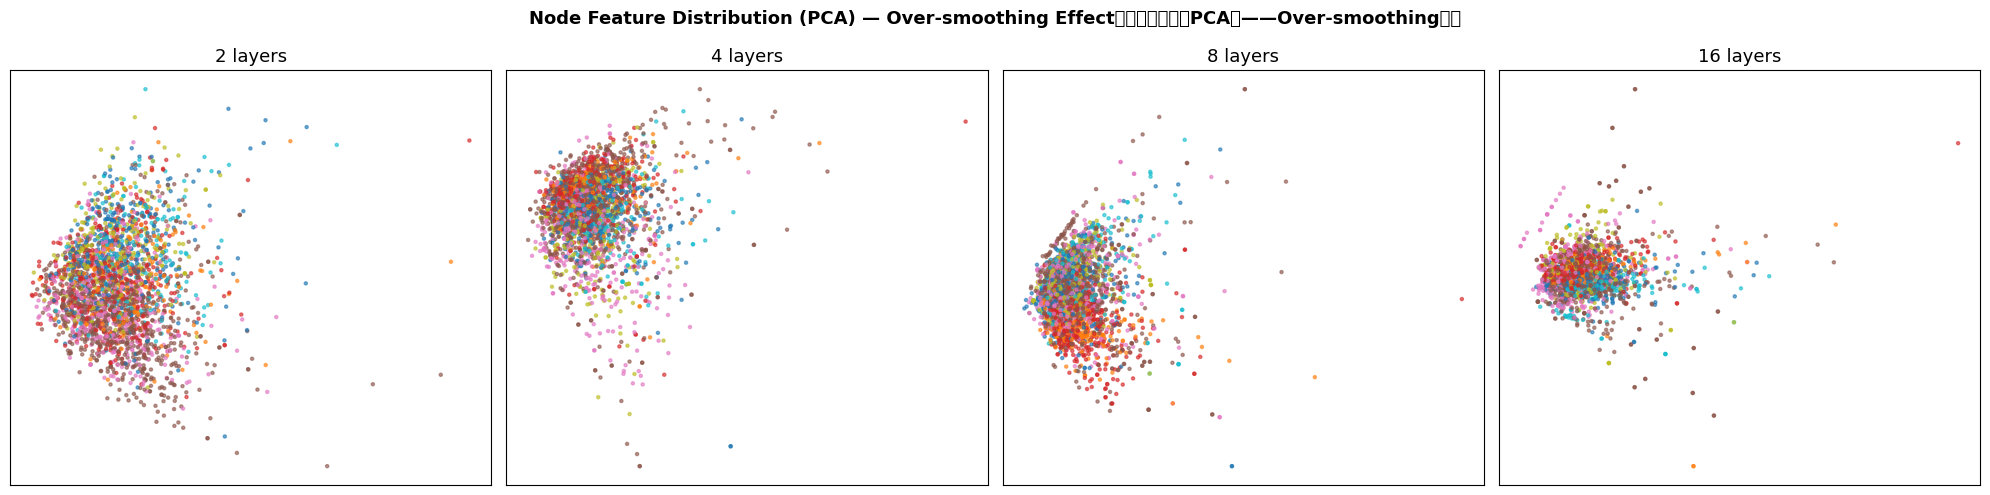

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
layer_counts = [2, 4, 8, 16]

for ax, num_layers in zip(axes, layer_counts):
    model_vis = DeepGCN(
        in_channels=dataset.num_features,
        hidden_channels=64,
        out_channels=dataset.num_classes,
        num_layers=num_layers
    ).to(device)

    # 不训练，直接用随机权重看结构
    # 用训练好的模型效果更好，这里用随机权重展示over-smoothing的纯粹效果
    model_vis.eval()
    with torch.no_grad():
        # 取最后一个隐藏层的输出（倒数第二层）
        x = data.x
        for i, conv in enumerate(model_vis.convs[:-1]):
            x = F.relu(conv(x, data.edge_index))

    # PCA 降维
    features = x.cpu().numpy()
    pca = PCA(n_components=2)
    features_2d = pca.fit_transform(features)

    # 按类别着色
    colors = cm.tab10(data.y.cpu().numpy() / 6.0)
    ax.scatter(features_2d[:, 0], features_2d[:, 1],
               c=colors, s=5, alpha=0.6)
    ax.set_title(f"{num_layers} layers", fontsize=13)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Node Feature Distribution (PCA) — Over-smoothing Effect节点特征分布（PCA）——Over-smoothing效果",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
print("各层输出特征的标准差（越小 = 特征越趋同）：")
print("-" * 45)

for num_layers in [2, 4, 8, 16]:
    model_std = DeepGCN(
        in_channels=dataset.num_features,
        hidden_channels=64,
        out_channels=dataset.num_classes,
        num_layers=num_layers
    ).to(device)

    model_std.eval()
    with torch.no_grad():
        x = data.x
        for conv in model_std.convs[:-1]:
            x = F.relu(conv(x, data.edge_index))
        std = x.std().item()

    print(f"层数={num_layers:2d} | 特征标准差={std:.6f}")

各层输出特征的标准差（越小 = 特征越趋同）：
---------------------------------------------
层数= 2 | 特征标准差=0.051552
层数= 4 | 特征标准差=0.020819
层数= 8 | 特征标准差=0.005121
层数=16 | 特征标准差=0.000378


In [12]:
wandb.init(
    project="gnn-labs",
    name="gcn-cora-no-dropout",
    config={
        "model": "GCN",
        "dataset": "Cora",
        "hidden_channels": 64,
        "dropout": 0.0,   # 关键改动
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 200,
    }
)

model_no_dropout = GCN(
    in_channels=dataset.num_features,
    hidden_channels=64,
    out_channels=dataset.num_classes,
    dropout=0.0
).to(device)

In [13]:
for epoch in range(1, 201):
    train_loss = train(model_no_dropout)
    train_loss, val_loss, test_loss, train_acc, val_acc, test_acc = evaluate(model_no_dropout)

    wandb.log({
        "epoch": epoch,
        "train/loss": train_loss,
        "val/loss": val_loss,
        "test/loss": test_loss,
        "train/acc": train_acc,
        "val/acc": val_acc,
        "test/acc": test_acc,
    })

    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

wandb.finish()
print(f"\n最终测试准确率：{test_acc:.4f}")

Epoch 020 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 040 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 060 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 080 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 100 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 120 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 140 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 160 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980
Epoch 180 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 200 | train_loss=1.9481 train_acc=0.1714 | val_loss=1.9703 val_acc=0.0980


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇████
test/acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val/loss,█████████████▁█████████████████▁████████
epoch,200
test/acc,0.105
test/loss,1.96656
train/acc,0.17143



最终测试准确率：0.1050
